# 04 — Nanophotonic mapping (coupled-mode-theory schematic)

**Scope.** This is a *parameter mapping*, not an electromagnetic validation. We
do not solve Maxwell's equations. Evanescent coupling decays **exponentially**
with the gap, `t(d)=t0 e^{-d/L}`; a single `(t0,L)` reproduces the tight-binding
`(t1,t2)` **exactly**, so the operating point is realisable and self-consistent.
Absolute Purcell factors require a full-wave solver and are out of scope.

In [1]:
import sys; sys.path.insert(0, "../src")
import numpy as np, matplotlib.pyplot as plt
import nh_topo as nt
from nh_topo import plotting as P
cfg = nt.load_all(config_dir="../config"); p = nt.get_physics_params(cfg)
from pathlib import Path
def figdir(key): return Path("..") / nt.get_figure_dir(cfg, key)
print(f"t1={p['t1']}, t2={p['t2']}, gamma={p['gamma']}, N={p['N']}, "
      f"|nu|={nt.topological_invariant(p['t1'], p['t2'])}")

t1=0.8, t2=1.2, gamma=0.3, N=20, |nu|=1


decay length L = 0.493 a, t0 = 2.700
reproduced t1=0.8000, t2=1.2000, ratio=1.5000


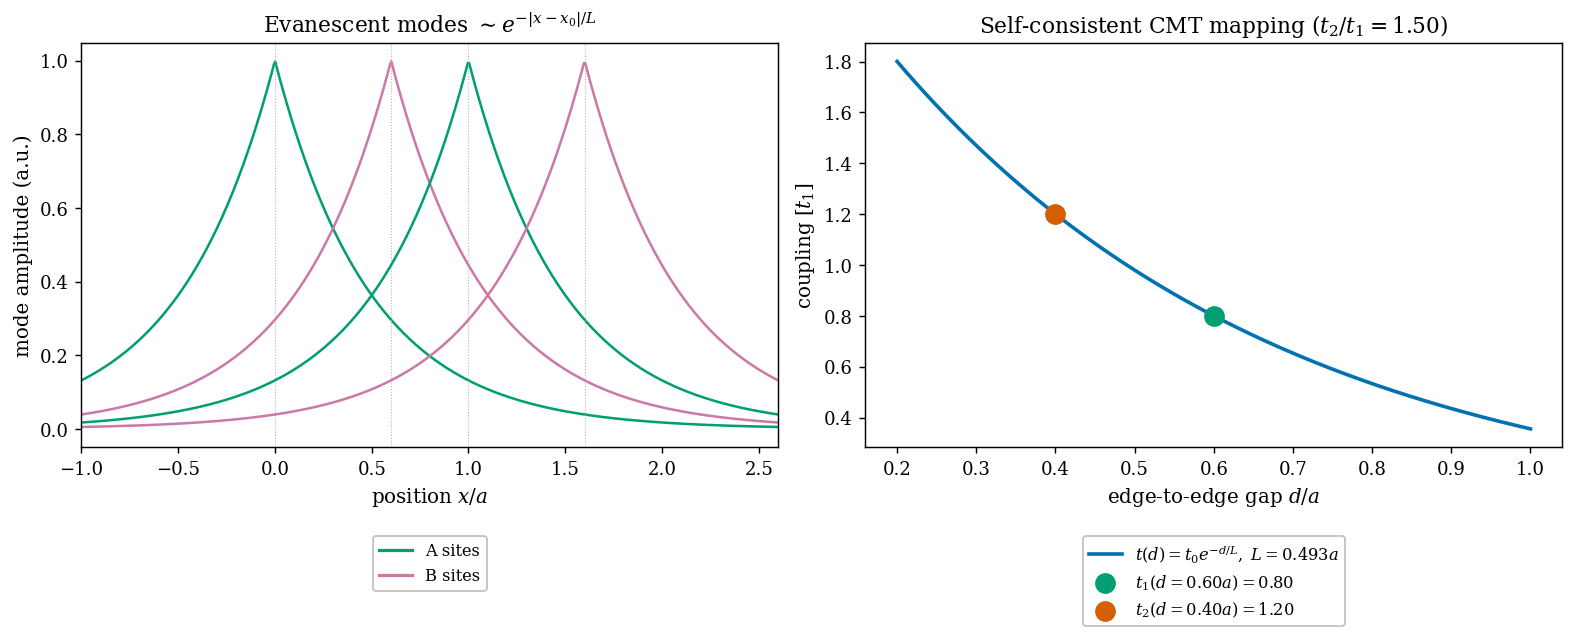

In [2]:
a, d1, d2 = p["a"], p["d_intra"]*p["a"], p["d_inter"]*p["a"]
cal = nt.calibrate_cmt(p["t1"], p["t2"], d1, d2)
print("decay length L = %.3f a, t0 = %.3f" % (cal["L"], cal["t0"]))
print("reproduced t1=%.4f, t2=%.4f, ratio=%.4f"
      % (cal["t1_reproduced"], cal["t2_reproduced"], cal["ratio_geom"]))
centers, modes, x = nt.build_resonator_chain(p["N"], a, d1, d2, cal["L"])
fig, _ = P.plot_cmt(x, a, centers, modes, cal, d1, d2)
P.save_fig(fig, figdir("04_effective_mode_nanophotonics"), "01_cmt_mapping"); plt.show()